# Sustainable Development Goals Readiness Index 2030

This Jupyter Notebook focuses on the construction and analysis of the **SDG Readiness Index 2030**, which aims to assess how prepared countries are to achieve selected United Nations Sustainable Development Goals by the year 2030.

The notebook combines the cleaned and processed sub-index datasets developed from:

* SDG 3 - Good Health and Well-Being
* SDG 6 - Clean Water and Sanitation
* SDG 11 - Sustainable Cities and Communities

The purpose of this notebook is to standardise and analyse the combined indicators using multivariate analysis techniques such as:

* Correlation Analysis
* Variance Inflation Factor (VIF)
* Principal Component Analysis (PCA)
* Clustering Analysis

These methods are used to identify relationships between indicators, reduce dimensionality and group countries based on similar SDG readiness patterns.

The final stage of this notebook will involve weighting and aggregating the indicators to produce the overall **SDG Readiness Index 2030** for comparative country analysis.


### 1.1 Merge Datasets

In [84]:
import pandas as pd

sdg3_combined_df = pd.read_csv("Raw_Data/SDG_3_Good_Health_and_Well-Being/sdg3_combined.csv")

sdg6_combined_df = pd.read_csv("Raw_Data/SDG_6_Clean_Water_and_Sanitation/sdg6_combined.csv")

sdg11_combined_df = pd.read_csv("Raw_Data/SDG_11_Sustainable_Cities_and_Communities/sdg11_combined.csv")


print("SDG 3 Combined Dataset")
display(sdg3_combined_df.head())

print("SDG 6 Combined Dataset")
display(sdg6_combined_df.head())

print("SDG 11 Combined Dataset")
display(sdg11_combined_df.head())

SDG 3 Combined Dataset


,GeoAreaName,InfantMortality_2030_Predicted,DiseaseMortality_2030_Predicted,SuicideMortality_2030_Predicted
0,Afghanistan,37.457082,28.517287,3.145842
1,Albania,5.546873,4.123085,0.537856
2,Algeria,15.713803,10.728556,1.129431
3,Andorra,1.295250,0.000000,0.000000
4,Angola,12.002988,22.855689,7.281947


SDG 6 Combined Dataset


,GeoAreaName,Stress_2030_Predicted,DrinkingWater_2030_Predicted,Handwashing_2030_Predicted
0,Afghanistan,54.760000,35.766557,56.782834
1,Albania,2.836051,79.785542,0.000000
2,Algeria,175.482805,69.398306,85.653658
3,American Samoa,0.000000,92.731402,0.000000
4,Andorra,11.443845,90.639996,0.000000


SDG 11 Combined Dataset


,GeoAreaName,SlumPopulation_2030_Predicted,DisasterAffected_2030_Predicted
0,Afghanistan,75.339061,1609.393514
1,Albania,-5.932409,902.918922
2,Algeria,5.469330,231.992181
3,Andorra,0.000000,-24.487979
4,Angola,81.406761,119.414922


In [85]:
# Merge all SDG datasets using only matching GeoAreaName values

sdg_combined_df = (sdg3_combined_df.merge(sdg6_combined_df, on="GeoAreaName", how="inner").merge(sdg11_combined_df, on="GeoAreaName", how="inner"))

# Display result
print("Final Combined Dataset Shape:", sdg_combined_df.shape)

display(sdg_combined_df)

Final Combined Dataset Shape: (200, 9)


,GeoAreaName,InfantMortality_2030_Predicted,DiseaseMortality_2030_Predicted,SuicideMortality_2030_Predicted,Stress_2030_Predicted,DrinkingWater_2030_Predicted,Handwashing_2030_Predicted,SlumPopulation_2030_Predicted,DisasterAffected_2030_Predicted
0,Afghanistan,37.457082,28.517287,3.145842,54.760000,35.766557,56.782834,75.339061,1609.393514
1,Albania,5.546873,4.123085,0.537856,2.836051,79.785542,0.000000,-5.932409,902.918922
2,Algeria,15.713803,10.728556,1.129431,175.482805,69.398306,85.653658,5.469330,231.992181
3,Andorra,1.295250,0.000000,0.000000,11.443845,90.639996,0.000000,0.000000,-24.487979
4,Angola,12.002988,22.855689,7.281947,1.870000,0.000000,37.643818,81.406761,119.414922
...,...,...,...,...,...,...,...,...,...
195,Viet Nam,10.267658,19.265208,7.793217,17.553621,61.855982,90.606391,35.549101,-0.126799
196,World,0.000000,15.644420,7.499344,17.541811,76.607072,84.120878,22.081276,0.000000
197,Yemen,24.906752,24.719147,3.306455,311.829231,0.000000,68.580315,37.762881,-2556.458024
198,Zambia,23.839560,23.789934,6.785777,10.861360,0.000000,18.842607,42.997446,4141.474159


#### 1.2 Meaning of Indicators

| Indicator                | Meaning                                                                                                             |
| --------------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| InfantMortality_2030_Predicted  | Infant mortality rate (deaths per 1,000 live births)                                                                |
| DiseaseMortality_2030_Predicted | Mortality rate attributed to cardiovascular disease, cancer, diabetes, or chronic respiratory disease (probability) |
| SuicideMortality_2030_Predicted | Suicide mortality rate, by sex (deaths per 100,000 population)                                                      |
| Stress_2030_Predicted           | Level of water stress, freshwater withdrawal as a proportion of available freshwater resources (%)                  |
| DrinkingWater_2030_Predicted    | Proportion of population using safely managed drinking water services, by urban/rural (%)                           |
| Handwashing_2030_Predicted      | Proportion of population with basic handwashing facilities on premises, by urban/rural (%)                          |
| SlumPopulation_2030_Predicted   | Proportion of urban population living in slums (%)                                                                  |
| DisasterAffected_2030_Predicted | Number of directly affected persons attributed to disasters per 100,000 population                                  |


### 2.1 Multivariate Analysis

#### 2.2 Heatmap

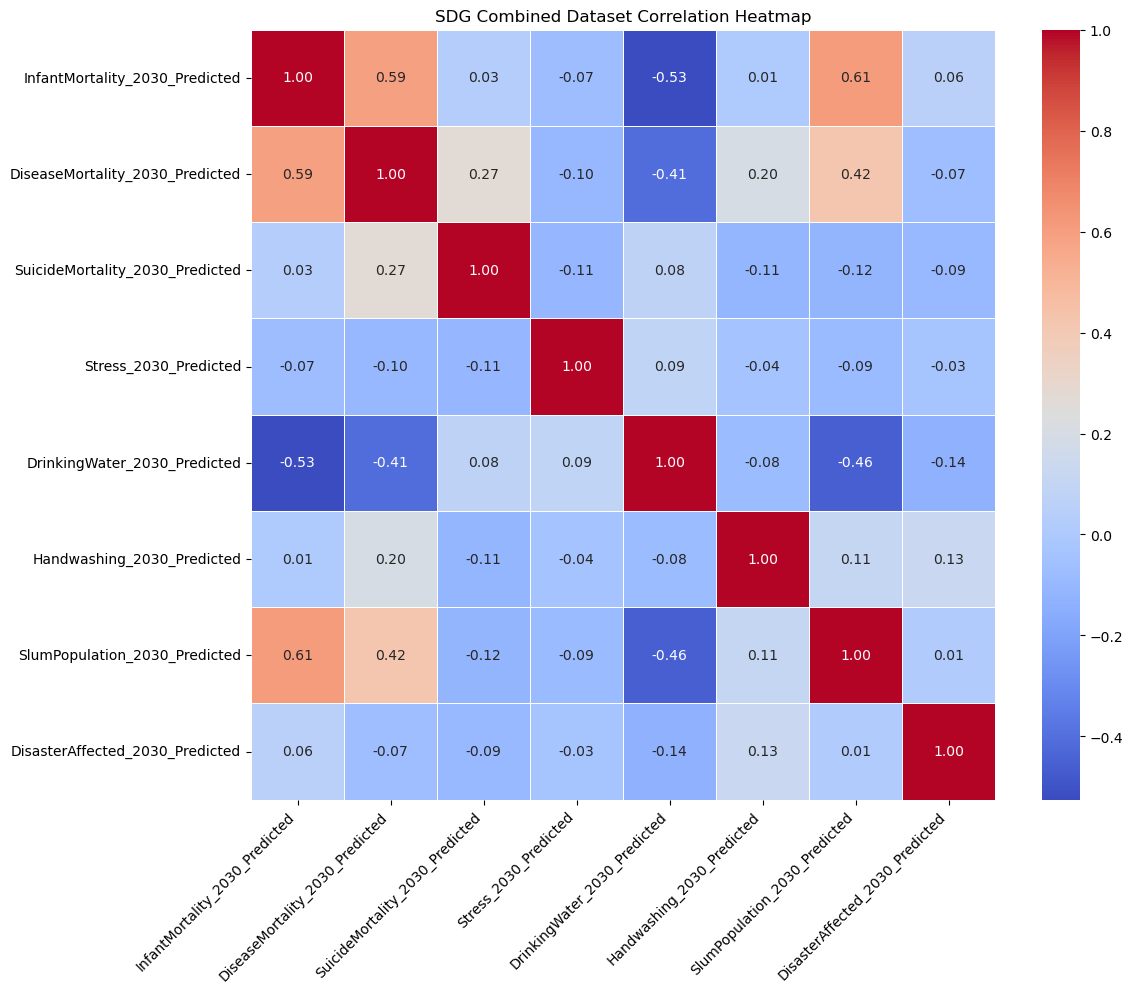

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

final_numeric = sdg_combined_df.select_dtypes(include='number')

correlation_matrix = final_numeric.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("SDG Combined Dataset Correlation Heatmap")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

Correlation Analysis & Multicollinearity Assessment

**1. Strong Positive Correlations**

- **SlumPopulation_2030_Predicted vs. InfantMortality_2030_Predicted (0.61)**: This represents the strongest positive correlation in the dataset. This correlation is expected, as poorer living conditions and limited healthcare access within slum areas naturally drive higher infant mortality rates. However, at 0.61, the correlation is not high enough to suggest problematic multicollinearity. Both variables capture the distinct socioeconomic factors.

- **InfantMortality_2030_Predicted vs. DiseaseMortality_2030_Predicted (0.59)**: This strong relationship reflects how weaker overall healthcare infrastructure impacts multiple health metrics simultaneously. Despite the overlap, they both measure fundamentally different aspects of public health.

- **SlumPopulation_2030_Predicted vs. DiseaseMortality_2030_Predicted (0.42)**: A moderate and reasonable correlation, highlighting how poor urban living conditions negatively affect long-term community health outcomes.

**2. Strong Negative Correlations**

- **InfantMortality_2030_Predicted vs. DrinkingWater_2030_Predicted (-0.53)**: This is the strongest negative correlation, which logically shows that better access to safe drinking water directly relates to lower infant mortality rates.

- **SlumPopulation_2030_Predicted vs. DrinkingWater_2030_Predicted (-0.46)**: This expected negative correlation indicates that regions with larger slum populations generally face steeper challenges in providing reliable clean water infrastructure.

- **DiseaseMortality_2030_Predicted vs. DrinkingWater_2030_Predicted (-0.41)**: This underscores how improved clean water access serves as a foundational driver for lowering disease mortality and lifting overall public health.

#### 2.3 PCA 

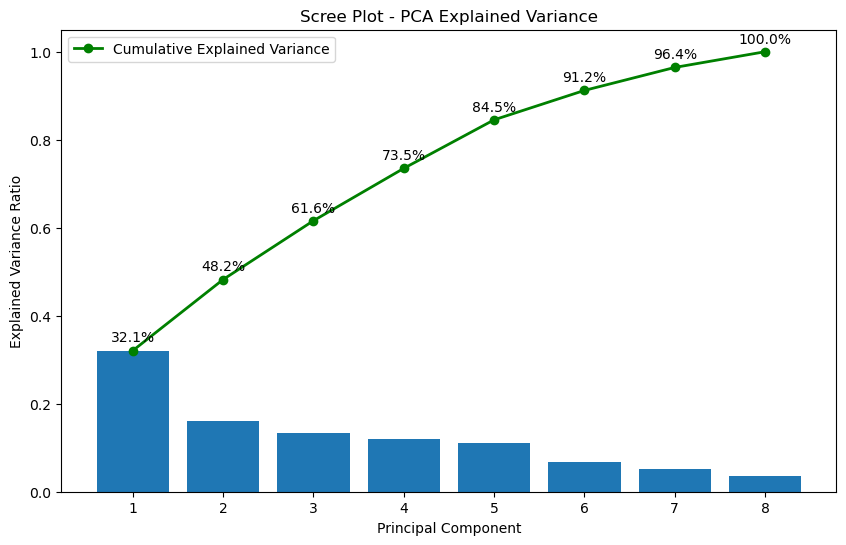

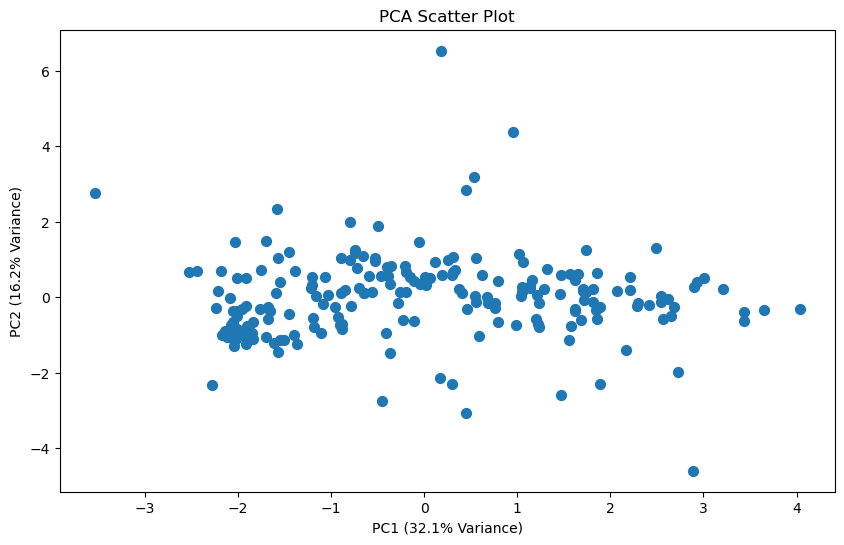

Kaiser Criterion Results


,Principal Component,Eigenvalue,Keep_Component
0,PC1,2.5779,True
1,PC2,1.2994,True
2,PC3,1.0746,True
3,PC4,0.9569,False
4,PC5,0.8869,False
5,PC6,0.5372,False
6,PC7,0.4201,False
7,PC8,0.2874,False



Number of PCs retained using Kaiser Criterion: 3


In [87]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

final_numeric = sdg_combined_df.select_dtypes(include='number')

# Standardising the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_numeric)

pca = PCA()
pca_components = pca.fit_transform(scaled_data)

# Scree Plot (Bar Chart)
plt.figure(figsize=(10, 6))

# Bar chart for explained variance
plt.bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_
)

# Line plot for cumulative variance
plt.plot(
    range(1, len(np.cumsum(pca.explained_variance_ratio_)) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker='o',
    linewidth=2,
    color='green',
    label='Cumulative Explained Variance'
)

# Adding percentage labels above each cumulative variance point
for i, value in enumerate(np.cumsum(pca.explained_variance_ratio_), start=1):
    plt.text(
        i,
        value + 0.02,
        f"{value * 100:.1f}%",
        ha='center'
    )

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot - PCA Explained Variance")

plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(False) # data to ink ratio yet again ;O
plt.legend()

plt.show()

# PCA Scatter Plot (PC1 vs PC2)
plt.figure(figsize=(10, 6))

plt.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    s=50
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% Variance)")
plt.title("PCA Scatter Plot")
plt.grid(False) # data to ink ratio ;)
plt.show()

# Kaiser Criterion 
kaiser_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_))],
    'Eigenvalue': pca.explained_variance_,
    'Keep_Component': pca.explained_variance_ > 1
})
# Only retain PCs with eigenvalues greater than 1

print("Kaiser Criterion Results")
display(kaiser_df.round(4))

print(f"\nNumber of PCs retained using Kaiser Criterion: {(pca.explained_variance_ > 1).sum()}")

In my opinion, the PCA results show a fairly balanced spread of variance across multiple components rather than having a single dominant factor controlling the dataset. The scree plot indicates that PC1 explains approximately **32.1%** of the total variance, while PC2 explains around **16.2%**. Together, the first two principal components account for roughly **48.2%** of the dataset's variance.

I believe this is a positive outcome because it suggests that the SDG indicators are not overly dependent on one another and that the dataset captures multiple dimensions of performance across countries. If one component had explained the majority of the variance alone, it could indicate excessive overlap or redundancy between the variables I selected.

The cumulative variance reaching approximately **73.5% by PC4** and **84.5% by PC5** suggests that a relatively small number of principal components are capable of preserving most of the information contained within the original dataset. In my opinion, this demonstrates that the dataset structure is reasonably efficient while still maintaining diversity between indicators.

The Kaiser Criterion results further support this interpretation, with only the first **3 principal components** having eigenvalues > 1. I personally think this is a strong indication that these three PCs contain the most meaningful and statistically useful variation in the dataset, while the remaining components contribute relatively limited additional variance.

#### 2.4 K-Means Clustering

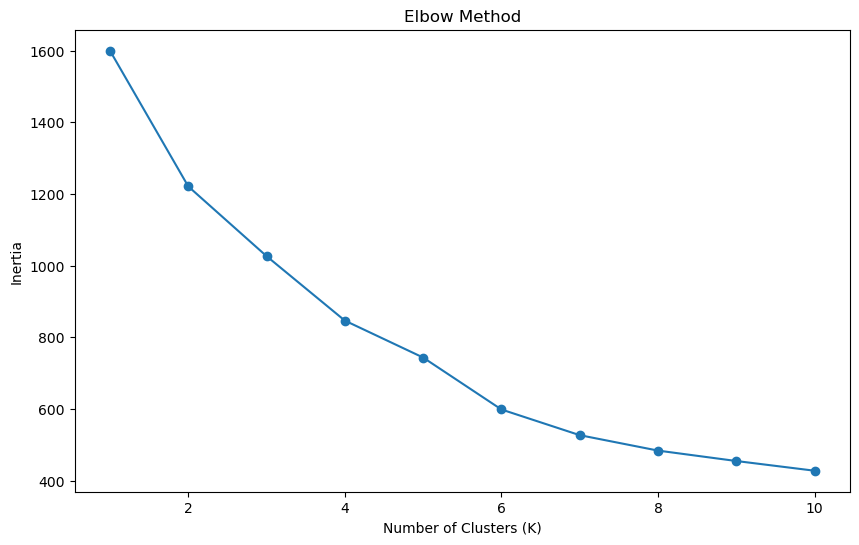

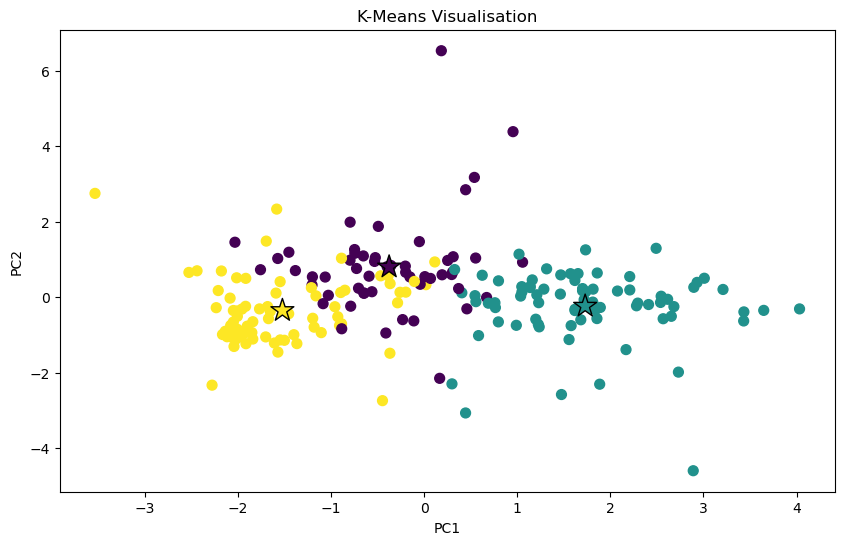

In [88]:
import os
import warnings as wrn

os.environ["OMP_NUM_THREADS"] = "1"

# Prevents this error leak
# anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
wrn.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak"
)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

final_numeric = sdg_combined_df.select_dtypes(include='number')

# Standardising the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_numeric)

# Elbow Method to find optimal K
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))

plt.plot(K_range,inertia,marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(False) # data to ink ratio yet again ;O

plt.show()

# Apply K-Means using chosen K
kmeans = KMeans( n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to dataset
sdg_combined_df['Cluster'] = clusters

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    c=clusters,
    s=50
)

# Plot centroids using same cluster colours
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c=range(kmeans.n_clusters),
    s=300,
    marker='*',
    edgecolor='black'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Visualisation")

plt.grid(False) # data to ink ratio ;)
plt.show()

In my opinion, the elbow plot suggests that using around **3 clusters** is a reasonable choice for this dataset. The inertia value drops quite sharply between K=1 and K=3, which indicates that adding additional clusters during this stage significantly improves how well the data points are grouped. After K=3, the curve begins to flatten out more gradually, meaning that adding more clusters provides smaller improvements and starts to introduce diminishing returns.

I personally chose 3 clusters because it seems to provide a good balance between simplifying the dataset and still capturing meaningful differences between countries. Choosing too many clusters could make the results harder to interpret, while too few clusters may oversimplify the patterns within the SDG indicators.

Looking at the K-Means visualisation, the clusters appear reasonably separated across the PCA space, particularly along the PC1 axis. In my opinion, this suggests that the dataset contains noticeable variation between the groups of countries in terms of their overall SDG performance patterns.

The centroids represent the centre point of each cluster, meaning they reflect the average position of countries belonging to that group. I think the spread of the data around the centroids is fairly realistic because countries don't behave identically across all SDG indicators. Some overlap between clusters was expected due to similarities between countries.

I also noticed that the turquoise cluster appears more spread out compared to the others, particularly towards the positive PC1 direction. In my opinion, this may indicate that countries within this cluster have greater variability in their SDG characteristics, whereas the yellow cluster appears more compact, suggesting more similar development patterns among those countries.

### 3.1 Normalisation

In [89]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Keep only numeric columns for scaling
final_numeric = sdg_combined_df.select_dtypes(include='number')

# Z-score standardisation
scaler = StandardScaler()

scaled_data = scaler.fit_transform(final_numeric)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=final_numeric.columns,
    index=sdg_combined_df.index
)

scaled_df.insert(0, 'GeoAreaName', sdg_combined_df['GeoAreaName'])

display(scaled_df)

,GeoAreaName,InfantMortality_2030_Predicted,DiseaseMortality_2030_Predicted,SuicideMortality_2030_Predicted,Stress_2030_Predicted,DrinkingWater_2030_Predicted,Handwashing_2030_Predicted,SlumPopulation_2030_Predicted,DisasterAffected_2030_Predicted,Cluster
0,Afghanistan,1.790597,1.446930,-0.688020,-0.038569,-0.371570,0.489130,2.207571,-0.181572,-0.121044
1,Albania,-0.628333,-1.457748,-1.105854,-0.152995,0.723726,-0.952288,-1.021777,-0.206646,1.153100
2,Algeria,0.142364,-0.671218,-1.011076,0.227472,0.465267,1.222009,-0.568725,-0.230459,-1.395187
3,Andorra,-0.950624,-1.948694,-1.192026,-0.134026,0.993810,-0.952288,-0.786050,-0.239562,1.153100
4,Angola,-0.138932,0.772790,-0.025361,-0.155124,-1.261525,0.003291,2.448673,-0.234455,-0.121044
...,...,...,...,...,...,...,...,...,...,...
195,Viet Nam,-0.270477,0.345262,0.056551,-0.120561,0.277596,1.347733,0.626505,-0.238698,-1.395187
196,World,-1.048810,-0.085874,0.009468,-0.120587,0.644638,1.183100,0.091356,-0.238693,-1.395187
197,Yemen,0.839229,0.994676,-0.662288,0.527942,-1.261525,0.788607,0.714470,-0.329429,-0.121044
198,Zambia,0.758331,0.884033,-0.104855,-0.135309,-1.261525,-0.473973,0.922467,-0.091701,-0.121044


After completing the multivariate analysis, including PCA and K-Means clustering, I decided that Z-score standardisation was the most appropriate normalisation technique for this dataset. In my opinion, this was the best approach because the SDG indicators are measured using completely different units and scales, such as mortality rates, percentages and even disaster-related population counts.

I chose Z-score standardisation because it transforms each variable relative to its own mean and standard deviation. This allows all my indicators to be placed onto a comparable scale while still preserving the variation between countries.

After standardisation, the values are centred around a mean of 0 with a standard deviation of approximately 1. This means that positive values represent countries performing above the average for a particular indicator, while negative values represent countries below the average.

Looking at the transformed results, some countries show very large positive Z-scores for indicators such as **SlumPopulation_2030_Predicted** and **InfantMortality_2030_Predicted**, suggesting that these countries are significantly above the dataset average for those measures. In my opinion, this highlights substantial developmental challenges within those countries compared to the rest of the dataset.

At the same time, many variables such as **Stress_2030_Predicted** appear more tightly distributed around zero, which suggests less variation between countries for that specific indicator. I think this demonstrates that some SDG measures vary much more strongly across countries than others.

### 4.1 Weighting and Aggregation

#### 4.2 Indicators Direction

In [91]:
# Goal: higher value = better SDG readiness

direction_df = scaled_df.copy()

# Negative indicators where higher value = worse
negative_indicators = [
    'InfantMortality_2030_Predicted',
    'DiseaseMortality_2030_Predicted',
    'SuicideMortality_2030_Predicted',
    'Stress_2030_Predicted',
    'SlumPopulation_2030_Predicted',
    'DisasterAffected_2030_Predicted'
]

# Reverse negative indicators
# This makes higher values represent better SDG readiness
direction_df[negative_indicators] = direction_df[negative_indicators] * -1

# Positive indicators are kept the same
positive_indicators = [
    'DrinkingWater_2030_Predicted',
    'Handwashing_2030_Predicted'
]

# Display first 5 rows after direction correction
display(direction_df)

,GeoAreaName,InfantMortality_2030_Predicted,DiseaseMortality_2030_Predicted,SuicideMortality_2030_Predicted,Stress_2030_Predicted,DrinkingWater_2030_Predicted,Handwashing_2030_Predicted,SlumPopulation_2030_Predicted,DisasterAffected_2030_Predicted,Cluster
0,Afghanistan,-1.790597,-1.446930,0.688020,0.038569,-0.371570,0.489130,-2.207571,0.181572,-0.121044
1,Albania,0.628333,1.457748,1.105854,0.152995,0.723726,-0.952288,1.021777,0.206646,1.153100
2,Algeria,-0.142364,0.671218,1.011076,-0.227472,0.465267,1.222009,0.568725,0.230459,-1.395187
3,Andorra,0.950624,1.948694,1.192026,0.134026,0.993810,-0.952288,0.786050,0.239562,1.153100
4,Angola,0.138932,-0.772790,0.025361,0.155124,-1.261525,0.003291,-2.448673,0.234455,-0.121044
...,...,...,...,...,...,...,...,...,...,...
195,Viet Nam,0.270477,-0.345262,-0.056551,0.120561,0.277596,1.347733,-0.626505,0.238698,-1.395187
196,World,1.048810,0.085874,-0.009468,0.120587,0.644638,1.183100,-0.091356,0.238693,-1.395187
197,Yemen,-0.839229,-0.994676,0.662288,-0.527942,-1.261525,0.788607,-0.714470,0.329429,-0.121044
198,Zambia,-0.758331,-0.884033,0.104855,0.135309,-1.261525,-0.473973,-0.922467,0.091701,-0.121044


#### 4.3 Weighting (Equal Weighting)

In [92]:
# Equal Weighting for Each SDG Indicator Group

# Create a copy of the direction-corrected dataframe
weighted_df = direction_df.copy()

sdg3_weight = 1 / 3

weighted_df['InfantMortality_Weighted'] = ( weighted_df['InfantMortality_2030_Predicted'] * sdg3_weight)
weighted_df['DiseaseMortality_Weighted'] = (weighted_df['DiseaseMortality_2030_Predicted'] * sdg3_weight)
weighted_df['SuicideMortality_Weighted'] = (weighted_df['SuicideMortality_2030_Predicted'] * sdg3_weight)

sdg6_weight = 1 / 3

weighted_df['Stress_Weighted'] = (weighted_df['Stress_2030_Predicted'] * sdg6_weight)
weighted_df['DrinkingWater_Weighted'] = (weighted_df['DrinkingWater_2030_Predicted'] * sdg6_weight)
weighted_df['Handwashing_Weighted'] = (weighted_df['Handwashing_2030_Predicted'] * sdg6_weight)

sdg11_weight = 1 / 2

weighted_df['SlumPopulation_Weighted'] = (weighted_df['SlumPopulation_2030_Predicted'] * sdg11_weight)
weighted_df['DisasterAffected_Weighted'] = (weighted_df['DisasterAffected_2030_Predicted'] * sdg11_weight)

# Display first 5 rows
display(weighted_df)

,GeoAreaName,InfantMortality_2030_Predicted,DiseaseMortality_2030_Predicted,SuicideMortality_2030_Predicted,Stress_2030_Predicted,DrinkingWater_2030_Predicted,Handwashing_2030_Predicted,SlumPopulation_2030_Predicted,DisasterAffected_2030_Predicted,Cluster,InfantMortality_Weighted,DiseaseMortality_Weighted,SuicideMortality_Weighted,Stress_Weighted,DrinkingWater_Weighted,Handwashing_Weighted,SlumPopulation_Weighted,DisasterAffected_Weighted
0,Afghanistan,-1.790597,-1.446930,0.688020,0.038569,-0.371570,0.489130,-2.207571,0.181572,-0.121044,-0.596866,-0.482310,0.229340,0.012856,-0.123857,0.163043,-1.103786,0.090786
1,Albania,0.628333,1.457748,1.105854,0.152995,0.723726,-0.952288,1.021777,0.206646,1.153100,0.209444,0.485916,0.368618,0.050998,0.241242,-0.317429,0.510888,0.103323
2,Algeria,-0.142364,0.671218,1.011076,-0.227472,0.465267,1.222009,0.568725,0.230459,-1.395187,-0.047455,0.223739,0.337025,-0.075824,0.155089,0.407336,0.284362,0.115230
3,Andorra,0.950624,1.948694,1.192026,0.134026,0.993810,-0.952288,0.786050,0.239562,1.153100,0.316875,0.649565,0.397342,0.044675,0.331270,-0.317429,0.393025,0.119781
4,Angola,0.138932,-0.772790,0.025361,0.155124,-1.261525,0.003291,-2.448673,0.234455,-0.121044,0.046311,-0.257597,0.008454,0.051708,-0.420508,0.001097,-1.224337,0.117227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Viet Nam,0.270477,-0.345262,-0.056551,0.120561,0.277596,1.347733,-0.626505,0.238698,-1.395187,0.090159,-0.115087,-0.018850,0.040187,0.092532,0.449244,-0.313252,0.119349
196,World,1.048810,0.085874,-0.009468,0.120587,0.644638,1.183100,-0.091356,0.238693,-1.395187,0.349603,0.028625,-0.003156,0.040196,0.214879,0.394367,-0.045678,0.119347
197,Yemen,-0.839229,-0.994676,0.662288,-0.527942,-1.261525,0.788607,-0.714470,0.329429,-0.121044,-0.279743,-0.331559,0.220763,-0.175981,-0.420508,0.262869,-0.357235,0.164714
198,Zambia,-0.758331,-0.884033,0.104855,0.135309,-1.261525,-0.473973,-0.922467,0.091701,-0.121044,-0.252777,-0.294678,0.034952,0.045103,-0.420508,-0.157991,-0.461233,0.045851


#### 4.4 Aggregation (Arithmetic Mean)

In [93]:
# Weighted Arithmetic Mean Aggregation

# SDG 3 Sub-Index
weighted_df['SDG3_SubIndex'] = (
    weighted_df['InfantMortality_Weighted'] +
    weighted_df['DiseaseMortality_Weighted'] +
    weighted_df['SuicideMortality_Weighted']
) / 3

# SDG 6 Sub-Index
weighted_df['SDG6_SubIndex'] = (
    weighted_df['Stress_Weighted'] +
    weighted_df['DrinkingWater_Weighted'] +
    weighted_df['Handwashing_Weighted']
) / 3

# SDG 11 Sub-Index
weighted_df['SDG11_SubIndex'] = (
    weighted_df['SlumPopulation_Weighted'] +
    weighted_df['DisasterAffected_Weighted']
) / 2

# Final SDG Readiness Index
weighted_df['Final_SDG_Index'] = (
    weighted_df['SDG3_SubIndex'] +
    weighted_df['SDG6_SubIndex'] +
    weighted_df['SDG11_SubIndex']
) / 3

# Display results
display(
    weighted_df[[
        'GeoAreaName',
        'SDG3_SubIndex',
        'SDG6_SubIndex',
        'SDG11_SubIndex',
        'Final_SDG_Index'
    ]]
)

,GeoAreaName,SDG3_SubIndex,SDG6_SubIndex,SDG11_SubIndex,Final_SDG_Index
0,Afghanistan,-0.283279,0.017348,-0.506500,-0.257477
1,Albania,0.354659,-0.008396,0.307106,0.217790
2,Algeria,0.171103,0.162201,0.199796,0.177700
3,Andorra,0.454594,0.019505,0.256403,0.243501
4,Angola,-0.067611,-0.122568,-0.553555,-0.247911
...,...,...,...,...,...
195,Viet Nam,-0.014593,0.193988,-0.096952,0.027481
196,World,0.125024,0.216481,0.036834,0.126113
197,Yemen,-0.130180,-0.111207,-0.096260,-0.112549
198,Zambia,-0.170834,-0.177799,-0.207691,-0.185442


Before applying weighting and aggregation, I first ensured that all indicators moved in the same direction. In my opinion, this was an important step because the final SDG readiness index should be interpreted consistently, where higher values always represent stronger SDG readiness and lower values represent weaker readiness.

Several indicators within the dataset naturally behaved as negative indicators, meaning higher values reflected poorer outcomes. These included infant mortality, disease mortality, suicide mortality, water stress, slum population and disaster-affected population. For example, a country with higher infant mortality or greater disaster impacts should not receive a higher readiness score. Because of this, I reversed these indicators after standardisation so that larger values would instead reflect more positive SDG performance.

On the other hand, drinking water access and handwashing access were already positive indicators because higher values naturally represent stronger infrastructure, sanitation and public health conditions. These variables therefore remained unchanged.

For the weighting stage, I decided to apply equal weighting across all indicators within each SDG category. In my opinion, this was the fairest and most balanced approach because the earlier multicollinearity analysis showed that the indicators were not strongly correlated with one another. Since the variables were relatively independent, I did not believe it would be appropriate to prioritise one indicator more heavily than another.

I also believe that each SDG goal represents a unique development issue that should contribute equally towards the final readiness index. For example, healthcare outcomes, water sustainability, sanitation access, urban living conditions and disaster resilience all reflect different dimensions of sustainable development. Even if some indicators explain more statistical variance than others, I personally felt that reducing the importance of certain SDG issues would create an unbalanced representation of country readiness.

Because of this, I used an equal weighting structure:

- SDG 3 indicators weighted equally
- SDG 6 indicators weighted equally
- SDG 11 indicators weighted equally

I then applied the Weighted Arithmetic Mean method to aggregate the indicators into SDG sub-indices and finally into a single overall SDG readiness index. In my opinion, the arithmetic mean was the most suitable aggregation technique because it is easy to interpret and commonly used in composite index construction. It also allows the final index to reflect the overall average readiness across the selected SDG dimensions while preserving the contribution of each individual indicator.